<a href="https://colab.research.google.com/github/F-Abir/GEE-Python-API/blob/main/Seasonal_Water_Deficit_Trend.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import ee
import geemap
import matplotlib.pyplot as plt

In [ ]:
!pip install xee
import xee
import xarray as xr

In [3]:
ee.Authenticate()
ee.Initialize(
    project = 'ee-abirnahraf',
    opt_url = 'https://earthengine-highvolume.googleapis.com'
)

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_7TDKVSyKvBdmMqW?ref=4i2o6


In [4]:

# Define the country boundary for Bangladesh
bangladesh = ee.FeatureCollection('FAO/GAUL/2015/level0').filter(ee.Filter.eq('ADM0_NAME', 'Bangladesh'))


In [ ]:
# Create a map centered on Bangladesh
Map = geemap.Map(center=[23.7, 90.4], zoom=7)

# Add the Bangladesh boundary as a layer to the map
Map.addLayer(bangladesh, {}, 'Bangladesh Boundary')

# Display the map
Map

In [8]:
collection = (
    ee.ImageCollection("IDAHO_EPSCOR/TERRACLIMATE")
    .filterDate('1980','2025')
    .select('def')
    .map(lambda img: img.multiply(0.1).copyProperties(img, img.propertyNames()))
)

collection


In [10]:
ds1 = xr.open_dataset(
    collection,
    engine = 'ee',
    crs = 'EPSG:4326',
    geometry = bangladesh.geometry(),
    scale = 0.05
)

In [11]:
ds2 = xr.open_dataset(
    collection,
    engine = 'ee',
    crs = 'EPSG:4326',
    geometry = bangladesh.geometry(),
    scale = 0.005
)

In [12]:
ds1_mean = ds1.mean(dim = ['lon', 'lat'])

In [13]:
ds2_mean = ds2.mean(dim = ['lon', 'lat'])

In [14]:
df1 = ds1_mean.to_dataframe()

In [15]:
df2 = ds2_mean.to_dataframe()

<Axes: xlabel='time'>

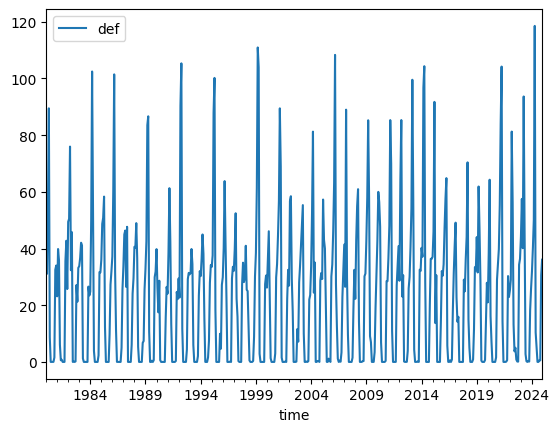

In [16]:
df1.plot()

<Axes: xlabel='time'>

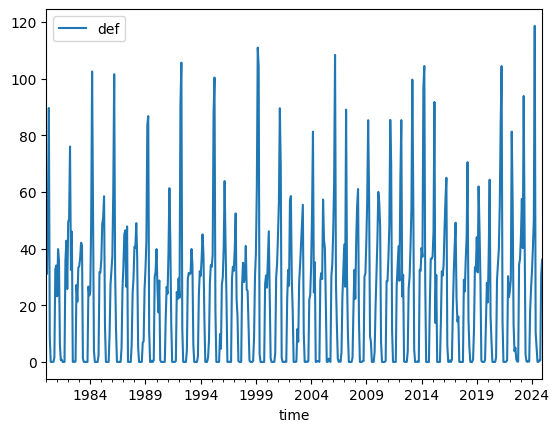

In [17]:
df2.plot()

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [19]:
model = seasonal_decompose(
    df1['def'],
    model = 'additive',
    period = 12
)

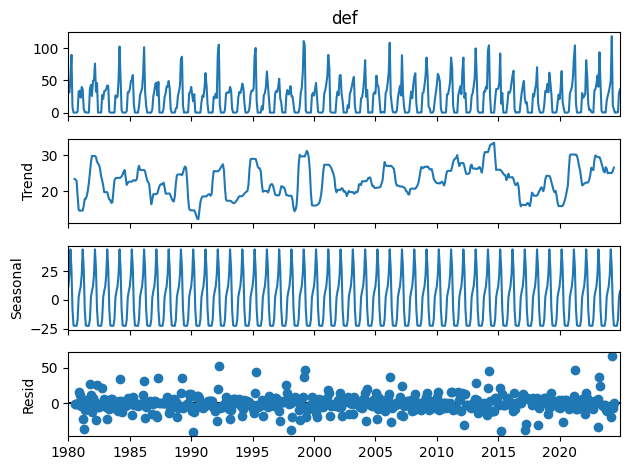

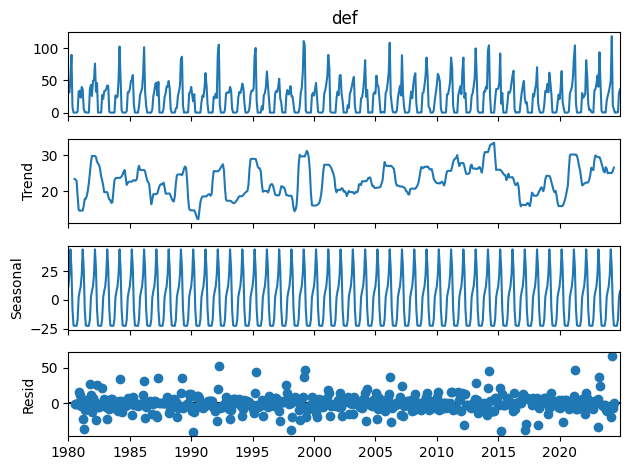

In [22]:
model.plot()

<Axes: xlabel='time'>

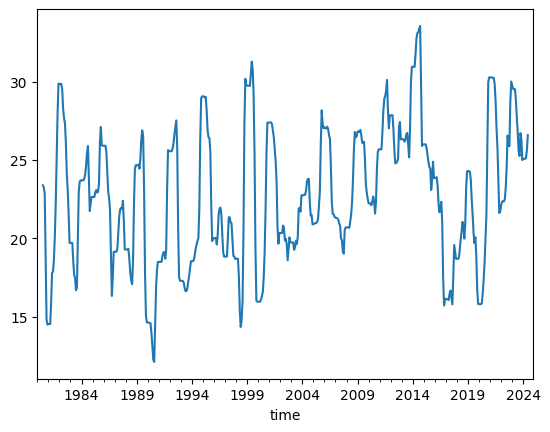

In [24]:
df_trend = model.trend

df_trend.plot()

In [26]:
!pip install pymannkendall
import pymannkendall as mk

In [28]:
!pip install pyhomogeneity
import pyhomogeneity as hg

In [29]:
mk_test = mk.original_test(df_trend)
hg_test = hg.pettitt_test(df_trend)
print(f'mk_test: {mk_test}')
print(f'hg_test: {hg_test}')

mk_test: Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(2.139591614991332e-09), z=np.float64(5.986838399504203), Tau=np.float64(0.1742783623713415), s=np.float64(24247.0), var_s=np.float64(16401559.0), slope=np.float64(0.00805467064600715), intercept=np.float64(20.187065845878397))
hg_test: Pettitt_Test(h=np.True_, cp=np.str_('2005-07-01'), p=np.float64(0.0), U=np.float64(24543.0), avg=mean(mu1=np.float64(21.52742773489298), mu2=np.float64(24.17423025275478)))
